#### Import

In [1]:
import sys
from pathlib import Path
import pandas as pd
import joblib

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
)
from xgboost import XGBClassifier

sys.path.insert(0, str(Path.cwd().parent))

from src.utils.config import GRAPH_FEATURES_CSV_PATH, SAVED_MODELS_DIR, TIME_SPLITS
from src.data.loader import load_and_prep_tabular_data

#### Load data

In [2]:
df = load_and_prep_tabular_data()

graph_df = pd.read_csv(GRAPH_FEATURES_CSV_PATH)

df = df.merge(graph_df, on="txId", how="left")
df.head()

,txId,time_step,local_0,local_1,local_2,local_3,local_4,local_5,local_6,local_7,...,agg_68,agg_69,agg_70,agg_71,class,y,in_degree,out_degree,pagerank,clustering_coefficient
0,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.131155,0.677799,-0.120613,-0.119792,2,0,160,1,0.007200,0.000621
1,232029206,1,-0.005027,0.578941,-0.091383,4.380281,-0.063725,4.667146,0.851305,-0.163645,...,-0.131155,0.333211,-0.120613,-0.119792,2,0,59,1,0.001842,0.001130
2,232344069,1,-0.147852,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.137933,...,-0.131155,-0.097524,-0.120613,-0.119792,2,0,0,2,0.000041,0.000000
3,27553029,1,-0.151357,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.141519,...,-0.131155,-0.097524,-0.120613,-0.119792,2,0,1,1,0.000058,0.000000
4,3881097,1,-0.172306,-0.184668,-1.201369,0.028105,-0.043875,-0.029140,0.242712,-0.163640,...,-0.084674,-0.054450,-1.760926,-1.760984,2,0,1,1,0.000041,0.000000


#### Split data

In [3]:
train_start, train_end = TIME_SPLITS["train"]
val_start, val_end = TIME_SPLITS["val"]
test_start, test_end = TIME_SPLITS["test"]

train_df = df[(df["time_step"] >= train_start) & (df["time_step"] <= train_end)].copy()
val_df = df[(df["time_step"] >= val_start) & (df["time_step"] <= val_end)].copy()
test_df = df[(df["time_step"] >= test_start) & (df["time_step"] <= test_end)].copy()

print(f"Train size: {len(train_df)}")
print(f"Val size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

Train size: 29894
Val size: 4303
Test size: 5680


#### Sanity Check

In [4]:
print("XGBoost splits:")
print(f"  Train illicit: {(train_df['y']==1).sum()}, licit: {(train_df['y']==0).sum()}")
print(f"  Val   illicit: {(val_df['y']==1).sum()}, licit: {(val_df['y']==0).sum()}")
print(f"  Test  illicit: {(test_df['y']==1).sum()}, licit: {(test_df['y']==0).sum()}")

print("\nTrain target distribution:")
print(train_df['y'].value_counts())
print(f"scale_pos_weight = {(train_df['y']==0).sum() / (train_df['y']==1).sum():.4f}")

XGBoost splits:
  Train illicit: 3462, licit: 26432
  Val   illicit: 366, licit: 3937
  Test  illicit: 548, licit: 5132

Train target distribution:
y
0    26432
1     3462
Name: count, dtype: int64
scale_pos_weight = 7.6349


#### Define feature columns

In [5]:
exclude_cols = ["txId", "class", "y", "time_step", "in_degree", "out_degree", "pagerank", "clustering_coefficient"]
base_feature_cols = [c for c in df.columns if c not in exclude_cols]

graph_feature_cols = ["in_degree", "out_degree", "pagerank", "clustering_coefficient"]


feature_cols_A = base_feature_cols
feature_cols_B = base_feature_cols + ["time_step"]
feature_cols_C = base_feature_cols + graph_feature_cols + ["time_step"]
feature_cols_D = [c for c in df.columns if c.startswith('local_')]

print(len(feature_cols_A))
print(len(feature_cols_B))
print(len(feature_cols_C))
print(len(feature_cols_D))

165
166
170
93


#### Multi-seed

In [6]:
import numpy as np
from sklearn.metrics import precision_score, average_precision_score, f1_score, recall_score
from xgboost import XGBClassifier
import sys
sys.path.insert(0, '..')
from src.utils.multiseed import run_multiseed

def run_xgboost_multiseed(train_df, val_df, test_df, feature_cols, exp_name, seeds=[42, 0, 123]):
    X_train, y_train = train_df[feature_cols], train_df["y"]
    X_val, y_val = val_df[feature_cols], val_df["y"]
    X_test, y_test = test_df[feature_cols], test_df["y"]

    n_pos = (y_train == 1).sum()
    n_neg = (y_train == 0).sum()
    scale_pos_weight = n_neg / n_pos

    def run_single_seed(seed):
        model = XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=seed, 
            n_jobs=-1,
            scale_pos_weight=scale_pos_weight,
            early_stopping_rounds=20,
        )

        model.fit(
            X_train, y_train,
            eval_set=[(X_train, y_train), (X_val, y_val)],
            verbose=False,
        )

        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        f1_ill = f1_score(y_test, y_pred, pos_label=1)
        prec_ill = precision_score(y_test, y_pred, pos_label=1)
        rec_ill = recall_score(y_test, y_pred, pos_label=1)
        auc_pr = average_precision_score(y_test, y_prob)
        
        return {
            'f1_ill': f1_ill,
            'precision': prec_ill,
            'recall': rec_ill,
            'auc_pr': auc_pr
        }

    return run_multiseed(run_single_seed, exp_name=exp_name, seeds=seeds)

run_xgboost_multiseed(train_df, val_df, test_df, feature_cols_A, "Version A (Graph-free)")
run_xgboost_multiseed(train_df, val_df, test_df, feature_cols_D, "Version D (Local-only)")


Version A (Graph-free) - Seed: 42

Version A (Graph-free) - Seed: 0

Version A (Graph-free) - Seed: 123

 Version A (Graph-free) multi-seed results
F1(illicit): 0.8643 ± 0.0031
Precision  : 0.9027 ± 0.0059
Recall     : 0.8291 ± 0.0009
AUC-PR     : 0.8929 ± 0.0007

Version D (Local-only) - Seed: 42

Version D (Local-only) - Seed: 0

Version D (Local-only) - Seed: 123

 Version D (Local-only) multi-seed results
F1(illicit): 0.7958 ± 0.0033
Precision  : 0.7688 ± 0.0059
Recall     : 0.8248 ± 0.0026
AUC-PR     : 0.8830 ± 0.0011


[{'f1_ill': 0.7926509186351706,
  'precision': 0.761344537815126,
  'recall': 0.8266423357664233,
  'auc_pr': 0.8841733648793031,
  'seed': 42},
 {'f1_ill': 0.8003533568904594,
  'precision': 0.7756849315068494,
  'recall': 0.8266423357664233,
  'auc_pr': 0.8833579610284698,
  'seed': 0},
 {'f1_ill': 0.794351279788173,
  'precision': 0.7692307692307693,
  'recall': 0.8211678832116789,
  'auc_pr': 0.8815063009668961,
  'seed': 123}]

#### Define one experiment

In [7]:
def run_one_experiment(train_df, val_df, test_df, feature_cols, exp_name):
    X_train, y_train = train_df[feature_cols], train_df["y"]
    X_val, y_val = val_df[feature_cols], val_df["y"]
    X_test, y_test = test_df[feature_cols], test_df["y"]

    n_pos = (y_train == 1).sum()
    n_neg = (y_train == 0).sum()
    scale_pos_weight = n_neg / n_pos

    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight,
        early_stopping_rounds=20,
    )

    print(f"Training {exp_name}...")
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=False,
    )

    y_pred = model.predict(X_test)

    recall_illicit = recall_score(y_test, y_pred, pos_label=1)
    f1_macro = f1_score(y_test, y_pred, average="macro")
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n=== {exp_name} ===")
    print(f"n_features: {len(feature_cols)}")
    print(f"Recall (illicit=1): {recall_illicit:.4f}")
    print(f"F1-macro: {f1_macro:.4f}")
    print("Confusion matrix:")
    print(cm)
    print("Classification report:")
    print(classification_report(y_test, y_pred, digits=4))

    SAVED_MODELS_DIR.mkdir(parents=True, exist_ok=True)
    safe_name = exp_name.lower().replace(" ", "_").replace("(", "").replace(")", "").replace("&", "and")
    model_path = SAVED_MODELS_DIR / f"xgboost_notebook_{safe_name}.pkl"
    joblib.dump(model, model_path)
    print(f"Model saved -> {model_path}")

    return {
        "experiment": exp_name,
        "n_features": len(feature_cols),
        "recall_illicit": recall_illicit,
        "f1_macro": f1_macro,
        "model_path": str(model_path),
    }

#### Run experiments

In [8]:
result_A = run_one_experiment(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    feature_cols=feature_cols_A,
    exp_name="Version A (without time_step)",
)

result_B = run_one_experiment(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    feature_cols=feature_cols_B,
    exp_name="Version B (with time_step)",
)

result_C = run_one_experiment(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    feature_cols=feature_cols_C,
    exp_name="Version C (with Graph Features & time_step)",
)

result_D = run_one_experiment(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    feature_cols=feature_cols_D,
    exp_name="Version D (local features only, truly graph-free)",
)

Training Version A (without time_step)...

=== Version A (without time_step) ===
n_features: 165
Recall (illicit=1): 0.8303
F1-macro: 0.9275
Confusion matrix:
[[5087   45]
 [  93  455]]
Classification report:
              precision    recall  f1-score   support

           0     0.9820    0.9912    0.9866      5132
           1     0.9100    0.8303    0.8683       548

    accuracy                         0.9757      5680
   macro avg     0.9460    0.9108    0.9275      5680
weighted avg     0.9751    0.9757    0.9752      5680

Model saved -> D:\Document\2025.2\IT5023E_Graduation_Research_1\transaction-network-analysis\saved_models\xgboost_notebook_version_a_without_time_step.pkl
Training Version B (with time_step)...

=== Version B (with time_step) ===
n_features: 166
Recall (illicit=1): 0.8303
F1-macro: 0.9279
Confusion matrix:
[[5088   44]
 [  93  455]]
Classification report:
              precision    recall  f1-score   support

           0     0.9820    0.9914    0.9867      51

#### Result

In [9]:
pd.DataFrame([result_A, result_B, result_C, result_D])

,experiment,n_features,recall_illicit,f1_macro,model_path
0,Version A (without time_step),165,0.830292,0.927469,D:\Document\2025.2\IT5023E_Graduation_Research...
1,Version B (with time_step),166,0.830292,0.927933,D:\Document\2025.2\IT5023E_Graduation_Research...
2,Version C (with Graph Features & time_step),170,0.830292,0.924703,D:\Document\2025.2\IT5023E_Graduation_Research...
3,"Version D (local features only, truly graph-free)",93,0.826642,0.884727,D:\Document\2025.2\IT5023E_Graduation_Research...


#### Sanity check

In [10]:
import matplotlib.pyplot as plt

model_A = joblib.load(result_A["model_path"])

feat_imp = pd.Series(
    model_A.feature_importances_,
    index=feature_cols_A
).sort_values(ascending=False)

print("Top 20 features:")
print(feat_imp.head(20))

imp_local = feat_imp[feat_imp.index.str.startswith('local_')].sum()
imp_agg = feat_imp[feat_imp.index.str.startswith('agg_')].sum()

print(f"\nTop local vs agg breakdown:")
print(f"Local features total importance: {imp_local:.4f}")
print(f"Agg features total importance: {imp_agg:.4f}")

Top 20 features:
local_52    0.096306
local_45    0.068108
local_89    0.046861
agg_69      0.042791
local_54    0.033176
agg_9       0.032584
agg_6       0.032235
local_4     0.027039
local_22    0.023873
local_39    0.023620
agg_42      0.022923
agg_7       0.022218
local_58    0.022177
local_17    0.020946
local_24    0.020103
local_46    0.017739
local_21    0.016028
local_80    0.015634
local_13    0.014006
local_75    0.013764
dtype: float32

Top local vs agg breakdown:
Local features total importance: 0.6942
Agg features total importance: 0.3058


### **XGBoost Training Curve**
We plot the training and validation logloss over the boosting rounds for the Version A (Baseline) model to observe convergence and early stopping.

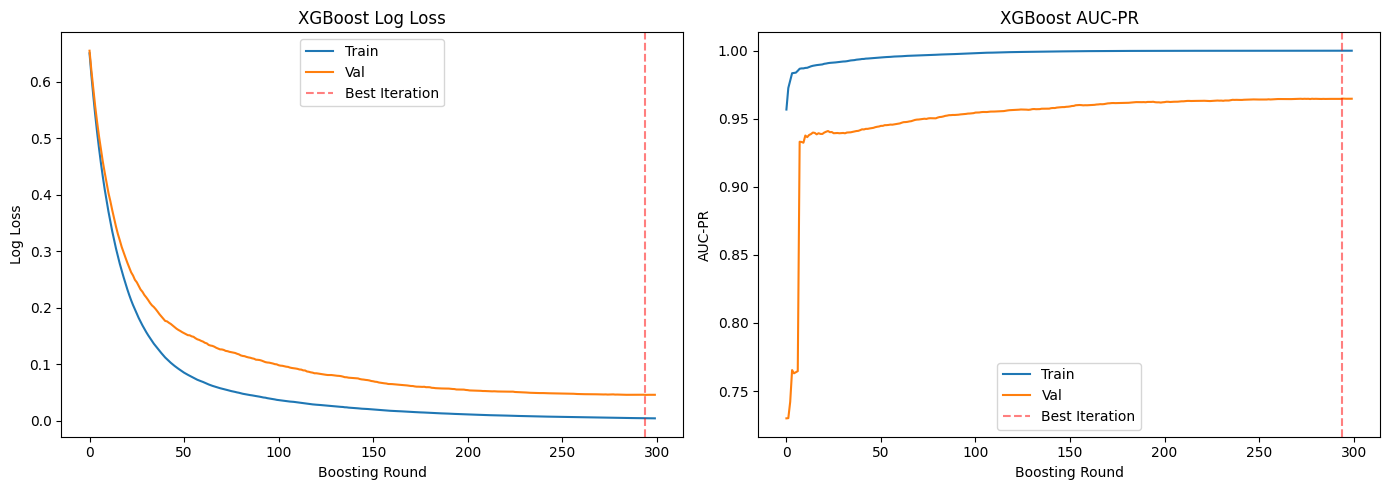

In [11]:
import matplotlib.pyplot as plt

# Re-run XGBoost Version A to extract evals_result for plotting
X_train, y_train = train_df[feature_cols_A], train_df["y"]
X_val, y_val = val_df[feature_cols_A], val_df["y"]

n_pos = (y_train == 1).sum()
n_neg = (y_train == 0).sum()
scale_pos_weight = n_neg / n_pos

model_plot = XGBClassifier(
    objective="binary:logistic",
    eval_metric=["logloss", "aucpr"],
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
    early_stopping_rounds=20,
)

model_plot.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

results = model_plot.evals_result()
epochs = len(results['validation_0']['logloss'])
x_axis = range(0, epochs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Log Loss
ax1.plot(x_axis, results['validation_0']['logloss'], label='Train')
ax1.plot(x_axis, results['validation_1']['logloss'], label='Val')
ax1.legend()
ax1.set_ylabel('Log Loss')
ax1.set_xlabel('Boosting Round')
ax1.set_title('XGBoost Log Loss')
if model_plot.best_iteration is not None:
    ax1.axvline(x=model_plot.best_iteration, color='red', linestyle='--', alpha=0.5, label='Best Iteration')
    ax1.legend()

# Plot AUC-PR
ax2.plot(x_axis, results['validation_0']['aucpr'], label='Train')
ax2.plot(x_axis, results['validation_1']['aucpr'], label='Val')
ax2.legend()
ax2.set_ylabel('AUC-PR')
ax2.set_xlabel('Boosting Round')
ax2.set_title('XGBoost AUC-PR')
if model_plot.best_iteration is not None:
    ax2.axvline(x=model_plot.best_iteration, color='red', linestyle='--', alpha=0.5, label='Best Iteration')
    ax2.legend()

plt.tight_layout()
plt.show()


### **Feature Importance (XGBoost Version A)**
The chart displays the top 20 most important features. `local_` features reflect internal transaction information, while `agg_` reflects statistical information from the neighborhood.

C:\Users\duong\AppData\Local\Temp\ipykernel_33744\3929467620.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_20.values, y=top_20.index, palette=colors)


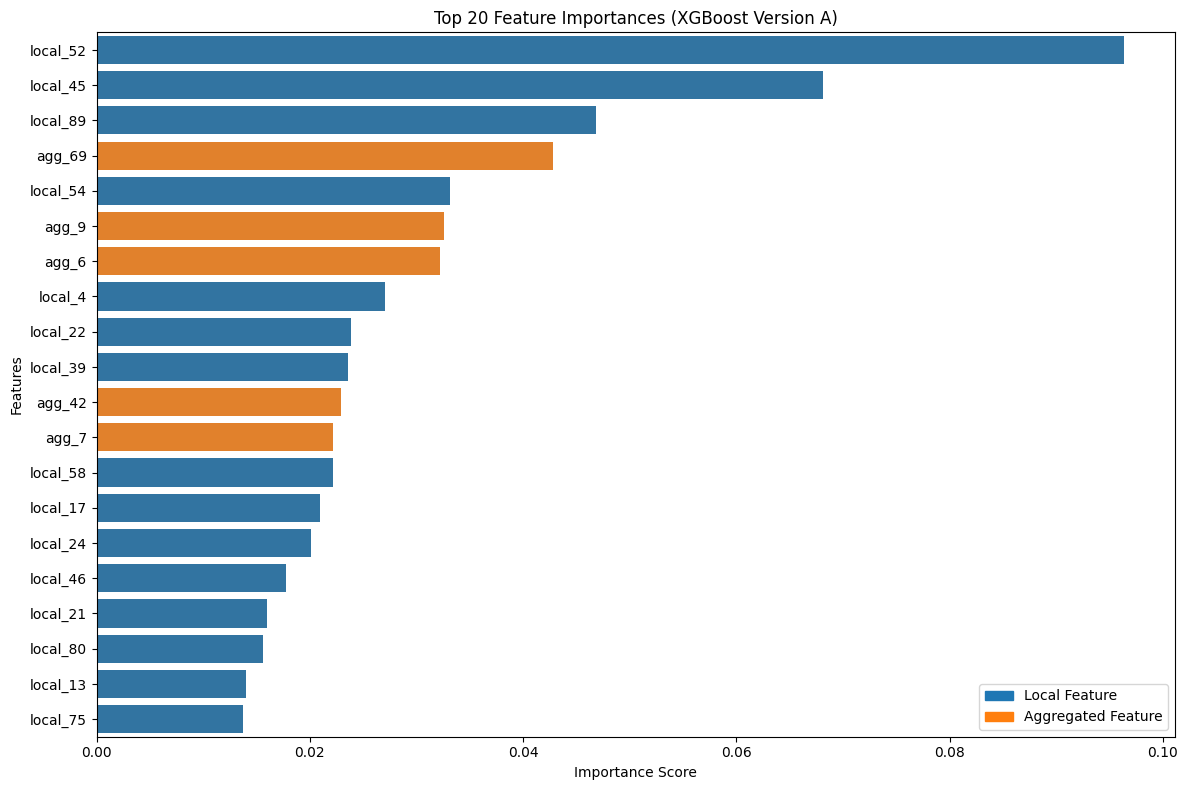

The overall importance of Local Features:69.42%
Overall Importance of Aggregated Features:30.58%


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

top_20 = feat_imp.head(20)

plt.figure(figsize=(12, 8))
colors = ['#1f77b4' if 'local' in feat else '#ff7f0e' for feat in top_20.index]

sns.barplot(x=top_20.values, y=top_20.index, palette=colors)
plt.title('Top 20 Feature Importances (XGBoost Version A)')
plt.xlabel('Importance Score')
plt.ylabel('Features')

import matplotlib.patches as mpatches
local_patch = mpatches.Patch(color='#1f77b4', label='Local Feature')
agg_patch = mpatches.Patch(color='#ff7f0e', label='Aggregated Feature')
plt.legend(handles=[local_patch, agg_patch], loc='lower right')

plt.tight_layout()
plt.show()

print(f"The overall importance of Local Features:{imp_local:.2%}")
print(f"Overall Importance of Aggregated Features:{imp_agg:.2%}")
